## Notebook purpose (conceptual overview)

This notebook analyzes **vector consistency across participants** and builds a simple **cheater/fraud detector**.

Conceptually:

- A participant produces vectors for many nonces.
- Other participants request a random subset of those nonces and recompute vectors locally.
- For each requested nonce, the verifier compares the received vector to its locally reconstructed vector.
- If the L2 distance exceeds a threshold, that nonce is a **mismatch**.

We calibrate the mismatch threshold from an **honest distance distribution** (98th percentile → ~2% expected mismatches), then use a **one-sided binomial test** to flag pairs/participants with significantly higher mismatch rates.

The final section runs **simulations** to show expected p-values under honest/cheater mismatch rates.

In [265]:
import json
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt



## Configure which runs to compare

You list the run directories to analyze.

Conceptually: each directory is a different participant/server run, producing a matrix of vectors over the same set of nonces. We’ll compare them pairwise to detect outliers.

In [266]:
# Configuration - update paths to the runs you want to compare
RUN_DIRS = [
    Path("/root/vllm/scripts/notebooks/data/A100_235B_int4_flashinfer"),
    Path("/root/vllm/scripts/notebooks/data/A100_235B_fp8_flashinfer"),
    Path("/root/vllm/scripts/notebooks/data/H100_235B_fp8"),
    Path("/root/vllm/scripts/notebooks/data/H100_235B_int4"),
    Path("/root/vllm/scripts/notebooks/data/B200_235B_fp8"),
]

# Labels used throughout the notebook (defaults to directory name)
RUN_LABELS = {p: p.name for p in RUN_DIRS}


## Load runs (configs + vector logs)

Each “run directory” represents one participant/server configuration (e.g., GPU type, dtype, quantization).

This cell:

- Loads `config.json` (metadata)
- Loads the single `*.json` data file containing recorded vectors (and optional nonces)
- Builds a common `data[...]` structure and a `servers` list used by the rest of the notebook

In [267]:
# Load config + vectors for each run directory
# Keep notebook output clean by default.
VERBOSE = False

configs = {}
data = {}


def _infer_marker(label: str, cfg: dict, run_dir: Path) -> str:
    """Infer run marker from label/model/path.

    We use:
    - fp8  -> "honest" marker
    - int4 -> "dishonest" marker

    Pair labeling later treats same-marker pairs (including int4-int4) as "honest".
    """
    s = f"{label} {cfg.get('model','')} {run_dir}".lower()
    if "fp8" in s:
        return "fp8"
    if "int4" in s:
        return "int4"
    return "unknown"


for run_dir in RUN_DIRS:
    label = RUN_LABELS.get(run_dir, run_dir.name)

    with open(run_dir / "config.json") as f:
        cfg = json.load(f)
    configs[label] = cfg

    # One data file per config/run (e.g. local_mlnode.json)
    json_files = [p for p in run_dir.glob("*.json") if p.name != "config.json"]
    if len(json_files) != 1:
        raise RuntimeError(
            f"{run_dir}: expected exactly 1 data json besides config.json, got {json_files}"
        )
    vec_path = json_files[0]

    with open(vec_path) as fp:
        d = json.load(fp)

    data[label] = {
        "vectors": np.array(d["vectors"]),
        "nonces": d.get("nonces", []),
        "server_name": d.get("server_name", vec_path.stem),
        "run_dir": str(run_dir),
        "marker": _infer_marker(label, cfg, run_dir),
    }

# Keep the same interface used by the rest of the notebook
servers = list(data.keys())
run_marker = {s: data[s]["marker"] for s in servers}

# Compact summary (no config dump)
rows = []
for s in servers:
    cfg = configs[s]
    model = cfg.get("model", "")
    model_short = model.split("/")[-1] if model else "-"
    rows.append((s, run_marker[s], data[s]["vectors"].shape, model_short))

pad = max((len(s) for s, *_ in rows), default=0)
print(f"Loaded {len(servers)} runs:")
for s, marker, shape, model_short in rows:
    print(f"- {s:<{pad}}  marker={marker:<7}  vectors={shape}  model={model_short}")


Loaded 5 runs:
- A100_235B_int4_flashinfer  marker=int4     vectors=(2000, 12)  model=Qwen3-235B-A22B-Instruct-2507-INT4-W4A16
- A100_235B_fp8_flashinfer   marker=fp8      vectors=(2000, 12)  model=Qwen3-235B-A22B-Instruct-2507-FP8
- H100_235B_fp8              marker=fp8      vectors=(2000, 12)  model=Qwen3-235B-A22B-Instruct-2507-FP8
- H100_235B_int4             marker=int4     vectors=(2000, 12)  model=Qwen3-235B-A22B-Instruct-2507-INT4-W4A16
- B200_235B_fp8              marker=fp8      vectors=(2000, 12)  model=Qwen3-235B-A22B-Instruct-2507-FP8


## Compute per-nonce distances between every pair of runs

For each pair of runs (servers/configurations), we compare vectors **nonce-by-nonce** (same index) and compute the L2 distance.

- Output: `pairwise_dists[(runA, runB)]` is an array of distances, one per nonce.
- Interpretation: small distances mean both runs reconstructed the vector similarly; large distances mean disagreement (potential cheating or numerical mismatch).

In [268]:
# Compute pairwise L2 distances for same nonces across servers
pairwise_dists = {}

pair_stats = []
for s1, s2 in itertools.combinations(servers, 2):
    v1, v2 = data[s1]["vectors"], data[s2]["vectors"]
    dists = np.linalg.norm(v1 - v2, axis=1)
    pairwise_dists[(s1, s2)] = dists
    pair_stats.append((s1, s2, float(np.mean(dists)), float(np.std(dists)), float(np.max(dists))))

# Compact summary: show only a few extremes
pair_stats_sorted = sorted(pair_stats, key=lambda x: x[2], reverse=True)
show_k = 8
print(f"Computed distances for {len(pairwise_dists)} run-pairs ({len(servers)} runs). Showing top-{min(show_k, len(pair_stats_sorted))} by mean distance:")
for s1, s2, mean, std, mx in pair_stats_sorted[:show_k]:
    print(f"- {s1} vs {s2}: mean={mean:.4f}, std={std:.4f}, max={mx:.4f}")


Computed distances for 10 run-pairs (5 runs). Showing top-8 by mean distance:
- H100_235B_int4 vs B200_235B_fp8: mean=0.2451, std=0.1018, max=1.1198
- A100_235B_int4_flashinfer vs B200_235B_fp8: mean=0.2446, std=0.1025, max=1.3202
- H100_235B_fp8 vs H100_235B_int4: mean=0.2444, std=0.1039, max=1.2914
- A100_235B_int4_flashinfer vs H100_235B_fp8: mean=0.2440, std=0.1045, max=1.4753
- A100_235B_fp8_flashinfer vs H100_235B_int4: mean=0.2418, std=0.1007, max=0.8875
- A100_235B_int4_flashinfer vs A100_235B_fp8_flashinfer: mean=0.2411, std=0.1009, max=1.0961
- H100_235B_fp8 vs B200_235B_fp8: mean=0.0772, std=0.0402, max=0.4224
- A100_235B_fp8_flashinfer vs B200_235B_fp8: mean=0.0708, std=0.0374, max=0.3272


## Label pairs using dtype markers (focus on fp8–fp8 baseline)

Instead of inferring “honest vs cheater” by distance clustering, we label each run using a simple marker:

- **fp8** → honest marker
- **int4** → dishonest marker

Then we define which comparisons we include:

- **Baseline (honest) pairs**: **fp8–fp8**
- **Test (dishonest) pairs**: **fp8–int4**
- **Excluded**: **int4–int4** (not analyzed)

We still use measured distances later, but **only** to set a mismatch threshold (from fp8–fp8) and compute mismatch rates/p-values.

In [269]:
# Label pairs using dtype markers (instead of distance clustering)
# We only analyze:
# - honest baseline: fp8 vs fp8
# - dishonest test:  fp8 vs int4
# We explicitly exclude int4 vs int4.

known = {"fp8", "int4"}

pairs = list(itertools.combinations(servers, 2))

low_dist_pairs = [
    (a, b)
    for a, b in pairs
    if (run_marker.get(a) == "fp8") and (run_marker.get(b) == "fp8")
]
high_dist_pairs = [
    (a, b)
    for a, b in pairs
    if ({run_marker.get(a), run_marker.get(b)} == {"fp8", "int4"})
]
excluded_int4_int4 = [
    (a, b)
    for a, b in pairs
    if (run_marker.get(a) == "int4") and (run_marker.get(b) == "int4")
]

unknown_runs = [s for s in servers if run_marker.get(s) not in known]

if not low_dist_pairs:
    raise RuntimeError(
        "No fp8-fp8 pairs found. Ensure your fp8 runs contain 'fp8' in label/model/path."
    )

print(
    f"Pair labels by marker: fp8-fp8={len(low_dist_pairs)}, fp8-int4={len(high_dist_pairs)}, excluded int4-int4={len(excluded_int4_int4)}"
    + (f" (unknown runs: {unknown_runs})" if unknown_runs else "")
)
if VERBOSE:
    for s in servers:
        print(f"- {s}: marker={run_marker.get(s)}")


Pair labels by marker: fp8-fp8=3, fp8-int4=6, excluded int4-int4=1


## Visualize separation between fp8–fp8 and fp8–int4 pairs

Using the earlier marker-based split into **baseline** (fp8–fp8) vs **test** (fp8–int4) *pairs of runs*, we plot their distance histograms.

Goal: give an intuitive picture of whether the fp8–int4 distances are well-separated from fp8–fp8.

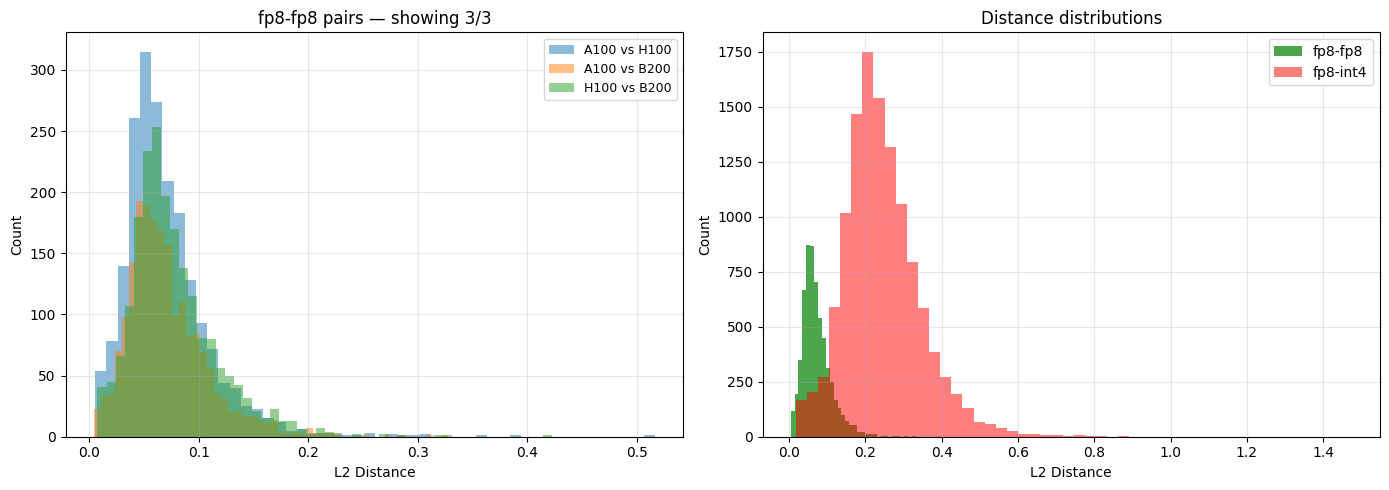

In [270]:
# Visualization - split honest vs dishonest (marker-labeled) pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

honest = {k: pairwise_dists[k] for k in low_dist_pairs}
dishonest = {k: pairwise_dists[k] for k in high_dist_pairs}

# Left: fp8-fp8 pairs (overlay a few for readability)
ax1 = axes[0]


def _gpu_type(run_label: str) -> str:
    s = str(run_label).upper()
    for tok in ("B200", "H100", "A100"):
        if tok in s:
            return tok
    return "UNKNOWN"


max_overlay = 6
shown = list(honest.items())[:max_overlay]
for (s1, s2), dists in shown:
    g1, g2 = _gpu_type(s1), _gpu_type(s2)
    ax1.hist(dists, bins=50, alpha=0.5, label=f"{g1} vs {g2}")
ax1.set_xlabel("L2 Distance")
ax1.set_ylabel("Count")
ax1.set_title(f"fp8-fp8 pairs — showing {min(max_overlay, len(honest))}/{len(honest)}")
ax1.grid(True, alpha=0.3)
if shown:
    ax1.legend(fontsize=9)

# Right: Combined honest vs combined dishonest
ax2 = axes[1]
all_honest = np.concatenate(list(honest.values())) if honest else np.array([], dtype=float)
all_dishonest = np.concatenate(list(dishonest.values())) if dishonest else np.array([], dtype=float)

if len(all_honest):
    ax2.hist(all_honest, bins=50, alpha=0.7, color="green", label="fp8-fp8")
if len(all_dishonest):
    ax2.hist(all_dishonest, bins=50, alpha=0.5, color="red", label="fp8-int4")

ax2.set_xlabel("L2 Distance")
ax2.set_ylabel("Count")
ax2.set_title("Distance distributions")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if VERBOSE and len(all_honest) and len(all_dishonest):
    print(
        f"Separation: honest_max={np.max(all_honest):.4f}, dishonest_min={np.min(all_dishonest):.4f}"
    )


## Build the honest distance distribution and choose a threshold

We estimate what “normal” looks like by pooling distances from pairs deemed **honest**.

Then we choose a decision threshold:

- `dist_threshold` = the **98th percentile** of the honest distance distribution
- This implies an expected honest mismatch rate of roughly **2%** (false positives)

We compute and print the empirical `fp_rate` to confirm that calibration.

In [271]:
from scipy.stats import binomtest

# Statistical fraud detection based on marker-labeled honest pairs

# 1. Estimate honest distribution from all honest pairs
all_honest_dists = np.concatenate([pairwise_dists[k] for k in low_dist_pairs])

# 2. Set threshold at percentile of honest distribution
percentile = 98
dist_threshold = float(np.percentile(all_honest_dists, percentile))

# 3. Estimate false positive rate from honest pairs
fp_count = int(np.sum(all_honest_dists > dist_threshold))
fp_rate = fp_count / len(all_honest_dists)

print(
    f"Honest dists n={len(all_honest_dists)}, dist_threshold(p{percentile})={dist_threshold:.6f}, fp_rate={fp_rate:.4f}"
)
if VERBOSE:
    print(
        f"  mean={np.mean(all_honest_dists):.6f}, std={np.std(all_honest_dists):.6f}, "
        f"median={np.median(all_honest_dists):.6f}, max={np.max(all_honest_dists):.6f}"
    )


Honest dists n=6000, dist_threshold(p98)=0.175523, fp_rate=0.0200


## Classifier-style summary (optional sanity check)

This cell treats the threshold rule as a binary classifier:

- **Score**: the per-nonce L2 distance
- **Predict cheater** if `distance > dist_threshold`

Using the earlier “honest vs cheater pair” split as a proxy ground truth, we compute a confusion matrix and derived rates (FPR/FNR). This is mainly a diagnostic to see how separable the distributions are.

In [272]:
# Classifier-style summary using marker-labeled pairs as proxy ground truth
# Positive class = "dishonest" (mixed-marker) pair; score = per-nonce distance

all_honest_dists = np.concatenate([pairwise_dists[k] for k in low_dist_pairs])
all_dishonest_dists = np.concatenate([pairwise_dists[k] for k in high_dist_pairs])

scores = np.concatenate([all_honest_dists, all_dishonest_dists])
y_true = np.concatenate(
    [
        np.zeros(len(all_honest_dists), dtype=int),
        np.ones(len(all_dishonest_dists), dtype=int),
    ]
)

# Prediction rule: flag as dishonest if distance is above the honest percentile threshold
y_pred = (scores > dist_threshold).astype(int)

TP = int(np.sum((y_true == 1) & (y_pred == 1)))
TN = int(np.sum((y_true == 0) & (y_pred == 0)))
FP = int(np.sum((y_true == 0) & (y_pred == 1)))
FN = int(np.sum((y_true == 1) & (y_pred == 0)))

total = int(len(y_true))
accuracy = (TP + TN) / total if total else float("nan")
fpr = FP / (FP + TN) if (FP + TN) else float("nan")
fnr = FN / (FN + TP) if (FN + TP) else float("nan")

print(
    f"Classifier: threshold={dist_threshold:.6f} | n_honest={len(all_honest_dists)} n_dishonest={len(all_dishonest_dists)} | acc={accuracy:.3f} fpr={fpr:.3f} fnr={fnr:.3f}"
)
if VERBOSE:
    print(f"TP={TP} FP={FP} TN={TN} FN={FN}")


Classifier: threshold=0.175523 | n_honest=6000 n_dishonest=12000 | acc=0.837 fpr=0.020 fnr=0.235


## Fraud detection as a binomial hypothesis test (per pair)

For each pair of runs (A vs B), we turn the distance checks into a mismatch count:

- For every nonce/vector, mark a **mismatch** if the distance exceeds `dist_threshold`.
- Under an honest pair, the mismatch probability should be close to `fp_rate` (~2%).

We then run a **one-sided** binomial test (alternative = "greater") to detect pairs whose mismatch rate is significantly **higher** than expected under honest behavior.

In [273]:
# 4. Test all pairs using a one-sided binomial test
# H0: pair is honest (mismatch rate = fp_rate)
# H1: pair has higher mismatch rate

fraud_threshold = 0.1  # p-value below this = flagged

results = []
for (s1, s2), dists in pairwise_dists.items():
    n_total = int(len(dists))
    n_exceed = int(np.sum(dists > dist_threshold))
    exceed_rate = n_exceed / n_total if n_total else float("nan")

    if fp_rate > 0:
        p_value = float(binomtest(n_exceed, n_total, fp_rate, alternative="greater").pvalue)
    else:
        p_value = 0.0 if n_exceed > 0 else 1.0

    flagged = p_value < fraud_threshold
    results.append((flagged, p_value, exceed_rate, n_exceed, n_total, s1, s2))

# Clean output: show only flagged pairs (or a short top-k list)
flagged_rows = [r for r in results if r[0]]
flagged_rows.sort(key=lambda r: r[1])

print(
    f"Fraud test: dist_threshold={dist_threshold:.6f}, fp_rate={fp_rate:.4f}, "
    f"flagged={len(flagged_rows)}/{len(results)} (p<{fraud_threshold})"
)

if flagged_rows:
    show_k = 10
    for _, p_value, exceed_rate, n_exceed, n_total, s1, s2 in flagged_rows[:show_k]:
        print(f"- {s1} vs {s2}: exceed={n_exceed}/{n_total} ({exceed_rate*100:.1f}%), p={p_value:.2e}")
elif VERBOSE:
    # Optional: in verbose mode, show the worst (largest exceed rates)
    results.sort(key=lambda r: r[2], reverse=True)
    for _, p_value, exceed_rate, n_exceed, n_total, s1, s2 in results[:10]:
        print(f"- {s1} vs {s2}: exceed={n_exceed}/{n_total} ({exceed_rate*100:.1f}%), p={p_value:.2e}")


Fraud test: dist_threshold=0.175523, fp_rate=0.0200, flagged=7/10 (p<0.1)
- A100_235B_int4_flashinfer vs A100_235B_fp8_flashinfer: exceed=1521/2000 (76.0%), p=0.00e+00
- A100_235B_int4_flashinfer vs H100_235B_fp8: exceed=1524/2000 (76.2%), p=0.00e+00
- A100_235B_int4_flashinfer vs B200_235B_fp8: exceed=1546/2000 (77.3%), p=0.00e+00
- A100_235B_fp8_flashinfer vs H100_235B_int4: exceed=1521/2000 (76.0%), p=0.00e+00
- H100_235B_fp8 vs H100_235B_int4: exceed=1521/2000 (76.0%), p=0.00e+00
- H100_235B_int4 vs B200_235B_fp8: exceed=1549/2000 (77.5%), p=0.00e+00
- H100_235B_fp8 vs B200_235B_fp8: exceed=50/2000 (2.5%), p=6.83e-02


## Visualize the honest threshold on distributions

We plot the empirical distance distributions:

- **Baseline (fp8–fp8)** distances
- **Test (fp8–int4)** distances

Then we draw the **98th-percentile fp8–fp8 threshold** as a vertical line. This visually explains why the threshold corresponds to ~2% false positives under the fp8–fp8 baseline.

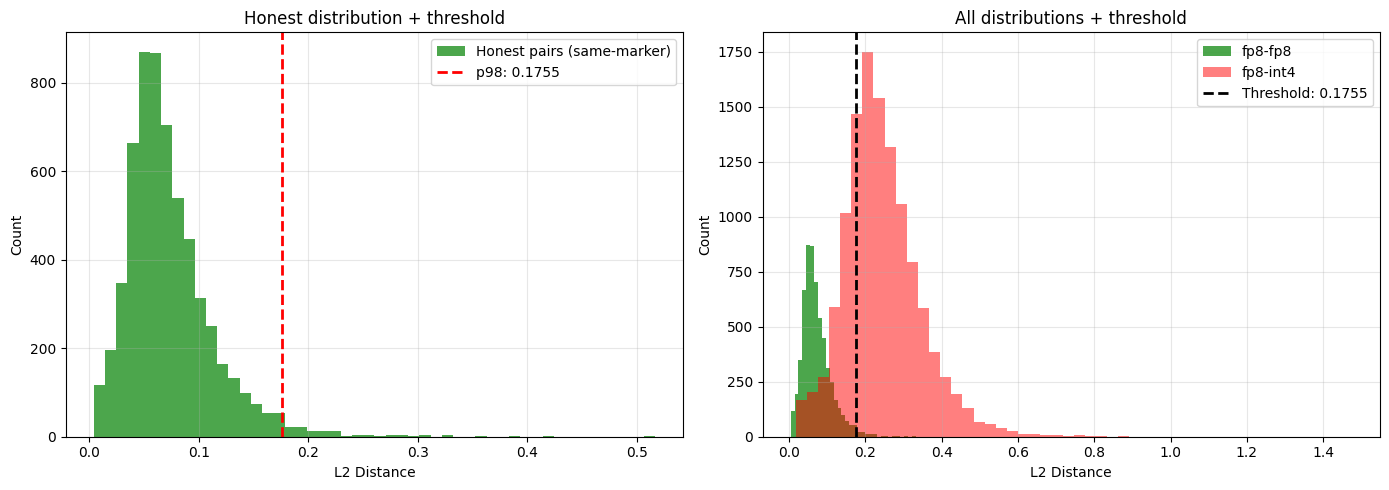

In [274]:
# 5. Visualize threshold on distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_dishonest_dists = np.concatenate([pairwise_dists[k] for k in high_dist_pairs])

# Left: Honest distribution with threshold
ax1 = axes[0]
ax1.hist(all_honest_dists, bins=50, alpha=0.7, color="green", label="Honest pairs (same-marker)")
ax1.axvline(
    dist_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"p{percentile}: {dist_threshold:.4f}",
)
ax1.set_xlabel("L2 Distance")
ax1.set_ylabel("Count")
ax1.set_title("Honest distribution + threshold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Honest vs dishonest with threshold
ax2 = axes[1]
ax2.hist(all_honest_dists, bins=50, alpha=0.7, color="green", label="fp8-fp8")
ax2.hist(all_dishonest_dists, bins=50, alpha=0.5, color="red", label="fp8-int4")
ax2.axvline(dist_threshold, color="black", linestyle="--", linewidth=2, label=f"Threshold: {dist_threshold:.4f}")
ax2.set_xlabel("L2 Distance")
ax2.set_ylabel("Count")
ax2.set_title("All distributions + threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if VERBOSE:
    dishonest_exceed = int(np.sum(all_dishonest_dists > dist_threshold))
    print(
        f"Dishonest nonces exceeding threshold: {dishonest_exceed}/{len(all_dishonest_dists)} "
        f"({dishonest_exceed/len(all_dishonest_dists)*100:.1f}%)"
    )


## Heatmap summary of pairwise distances

This cell summarizes all pairwise comparisons in one view:

- Each run is a row/column.
- Each cell shows the **mean** L2 distance (and **std**) between vectors from those two runs.

This is a quick diagnostic to spot clusters (similar runs) and outliers (potential cheater / incompatible configuration).

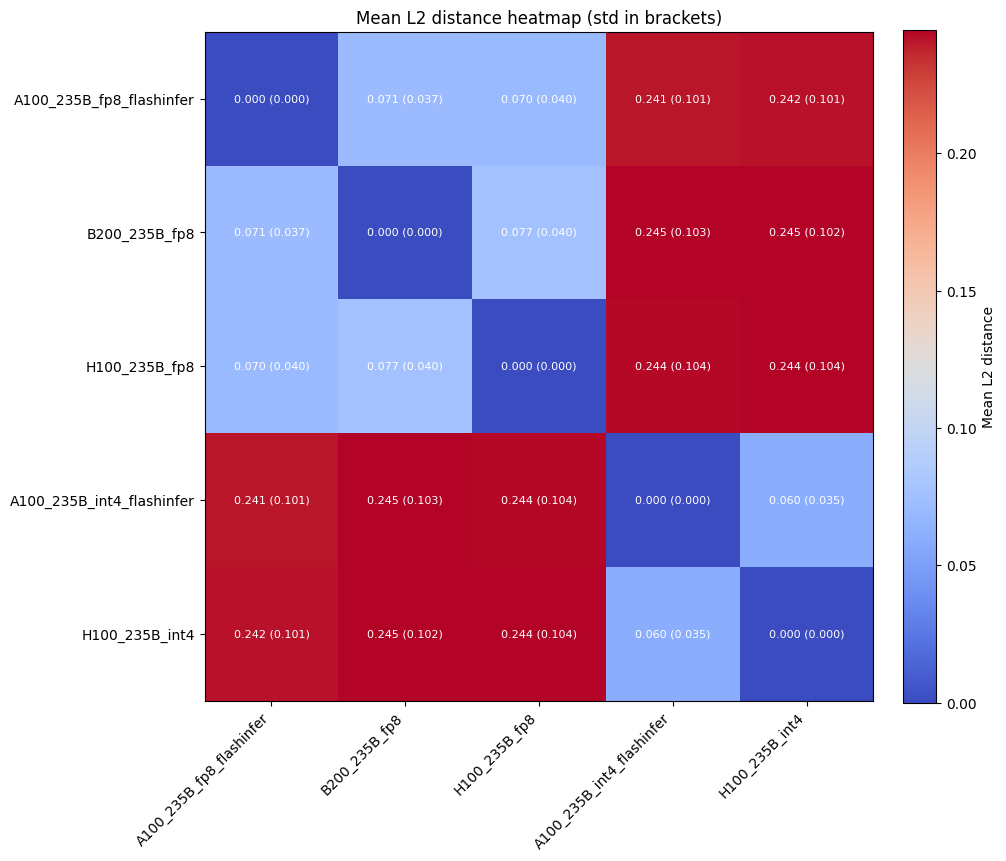

In [275]:
# Heatmap of mean pairwise distances (std in brackets)
# Rows/cols are runs; int4 runs are placed last.

def _is_int4(label: str) -> bool:
    s = label.lower()
    if "int4" in s:
        return True
    # fallback: check underlying path if present
    run_dir = data.get(label, {}).get("run_dir", "")
    return "int4" in str(run_dir).lower()

ordered = sorted(servers, key=lambda s: (_is_int4(s), s))

n = len(ordered)
mean_mat = np.zeros((n, n), dtype=float)
std_mat = np.zeros((n, n), dtype=float)

for i, a in enumerate(ordered):
    for j, b in enumerate(ordered):
        if i == j:
            mean_mat[i, j] = 0.0
            std_mat[i, j] = 0.0
            continue
        key = (a, b) if (a, b) in pairwise_dists else (b, a)
        dists = pairwise_dists[key]
        mean_mat[i, j] = float(np.mean(dists))
        std_mat[i, j] = float(np.std(dists))

fig, ax = plt.subplots(figsize=(1.6 * n + 2, 1.4 * n + 2))
im = ax.imshow(mean_mat, cmap="coolwarm")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(ordered, rotation=45, ha="right")
ax.set_yticklabels(ordered)
ax.set_title("Mean L2 distance heatmap (std in brackets)")

# annotate each cell with mean (std) using 3 digits
for i in range(n):
    for j in range(n):
        txt = f"{mean_mat[i, j]:.3f} ({std_mat[i, j]:.3f})"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color="white")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean L2 distance")

plt.tight_layout()
plt.show()


## Cheater simulation

We treat each participant-to-participant validation as a **binomial** process: out of \(N\) queried nonces, each nonce mismatch is a “success” with expected probability \(p_0 = 0.02\) (set by the honest 98th-percentile distance threshold). Below we simulate samples with \(N=200\) and varying mismatch counts.

## Simulation primitives (parameters + helper)

Defines the simulation knobs:

- `N`: number of queried vectors/nonces per participant (e.g. 200)
- `P0`: expected honest mismatch rate (2%) induced by the 98th-percentile distance threshold
- `MAX_MISMATCHES`: upper bound for the fixed-count sweep

Also defines `make_mismatch_sample(...)`, which builds a boolean array with **exactly** `mismatches` `True` values and randomizes their positions.

In [277]:
import numpy as np
from scipy.stats import binomtest

# Simulation parameters
N = 200
P0 = 1 - percentile / 100
MAX_MISMATCHES = 40

rng = np.random.default_rng(0)

def make_mismatch_sample(n: int, mismatches: int, rng: np.random.Generator) -> np.ndarray:
    """Boolean array of length n with exactly `mismatches` True values."""
    if mismatches < 0 or mismatches > n:
        raise ValueError("mismatches must be in [0, n]")
    x = np.zeros(n, dtype=bool)
    x[:mismatches] = True
    rng.shuffle(x)
    return x


In [278]:
# Generate simulated samples for mismatch counts 0..20
samples = {
    m: make_mismatch_sample(N, m, rng)
    for m in range(MAX_MISMATCHES + 1)
}


## Binomial test table (mismatch-count sweep)

We treat the mismatch indicator vector as a **binomial sample**:

- \(N\) trials (queried nonces)
- \(k\) mismatches (out-of-threshold distances)
- Honest null hypothesis: \(X \sim \text{Binomial}(N, p_0)\) with \(p_0=2\%\)

We report two different probabilities:

- **p_value**: one-sided binomial test p-value \(P(X \ge k \mid p_0)\) (only detects *higher-than-expected* mismatch rates)
- **P(X=k | p0)**: exact probability of seeing *exactly* \(k\) mismatches under the honest null

In [279]:
from scipy.stats import binom

# Binomial test for each sample: H0 p = 0.02
# One-sided: detect only if observed mismatch rate is higher than expected
print(f"Binomial test (one-sided, greater) vs p0={P0:.2%} with N={N}")

header = f"{'mismatches':>10}  {'observed_rate':>13}  {'p_value':>12}  {'P(X=k | p0)':>12}"
print(header)

for m in range(MAX_MISMATCHES + 1):
    x = samples[m]
    k = int(x.sum())
    rate = k / N
    p_value = binomtest(k, N, p=P0, alternative="greater").pvalue
    p_exact = binom.pmf(k, N, P0)
    print(f"{m:10d}  {rate:13.3%}  {p_value:12.4g}  {p_exact:12.4g}")


Binomial test (one-sided, greater) vs p0=2.00% with N=200
mismatches  observed_rate       p_value   P(X=k | p0)
         0         0.000%             1       0.01759
         1         0.500%        0.9824       0.07179
         2         1.000%        0.9106        0.1458
         3         1.500%        0.7649        0.1963
         4         2.000%        0.5685        0.1973
         5         2.500%        0.3712        0.1579
         6         3.000%        0.2133        0.1047
         7         3.500%        0.1086       0.05923
         8         4.000%       0.04934       0.02916
         9         4.500%       0.02017        0.0127
        10         5.000%      0.007479      0.004949
        11         5.500%      0.002531      0.001744
        12         6.000%     0.0007862     0.0005607
        13         6.500%     0.0002255     0.0001655
        14         7.000%     5.997e-05     4.511e-05
        15         7.500%     1.486e-05     1.142e-05
        16         8.000

## Monte Carlo setup: generate random cheater samples

We generate \(M\) independent boolean arrays of length \(N\):

- Each entry is `True` (= mismatch) with probability `P_CHEAT`.
- This models the **realized mismatch outcomes** a verifier would see if the true mismatch rate were higher than honest (e.g. 4% instead of 2%).

These samples are then fed into the binomial test in the next cell.

In [280]:
# Cheater-rate Monte Carlo: generate M samples with true mismatch rate p_cheat
M = 1000
P_CHEAT = P0 * 2
ALPHA = 0.05
N = 200
cheat_samples = rng.random((M, N)) < P_CHEAT  # shape: (M, N), dtype: bool


## Monte Carlo power check (how often cheaters get flagged)

Here we repeatedly simulate a participant validation outcome (a boolean vector of mismatches) under a **cheater mismatch rate** (e.g. 4%), then apply the **one-sided** binomial test against the honest baseline \(p_0=2\%\).

- **Summary**: how many of the \(M\) samples are flagged with p-value below `ALPHA` (an empirical detection rate / power estimate).

In [282]:
# Run one-sided binomial tests vs p0=2% and report detection rate
pvals = []

header = f"{'sample':>8}  {'mismatches':>10}  {'observed_rate':>13}  {'p_value':>12}"
# print(f"Monte Carlo with M={M}, N={N}, true_p={P_CHEAT:.2%} (test H0: p={P0:.2%}, alternative='greater')")
# print(header)

for i in range(M):
    k = int(cheat_samples[i].sum())
    rate = k / N
    p_value = binomtest(k, N, p=P0, alternative="greater").pvalue
    pvals.append(p_value)
    # print(f"{i:8d}  {k:10d}  {rate:13.3%}  {p_value:12.4g}")

pvals = np.array(pvals)
flagged = int((pvals < ALPHA).sum())
print()
print(f"p_value < {ALPHA:.2g}: {flagged}/{M} = {flagged/M:.1%}")



p_value < 0.05: 515/1000 = 51.5%


## Weighted voting simulation (vote-share range for honest vs dishonest targets)

Each validator checks a target participant using \(N\) queried nonces.

- A nonce is a **mismatch** if its distance exceeds the threshold.
- The validator observes a mismatch count \(k\) out of \(N\).
- It computes a **one-sided** p-value against the honest baseline \(p_0=2\%\): \(p = P(X \ge k \mid X \sim \text{Binomial}(N, p_0))\).

A validator then **votes “cheater”** if \(p < \alpha\).

Validators have different **weights** (stake / voting power). The target is marked as cheater if the **sum of weights** of “cheater” votes exceeds a **quorum** (typically 50% of total weight).

In the last cell we simulate voting rounds for two cases:

- **Honest target**: true mismatch rate \(p_{true}=2\%\)
- **Dishonest target**: true mismatch rate \(p_{true}=4\%\)

For each case we show the **range/quantiles** of the fraction of validators voting “cheater” (both unweighted and weight-weighted) and how often a **weighted majority** is reached.

In [283]:
import numpy as np
from scipy.stats import binom

try:
    import requests
except Exception:
    requests = None

# --- knobs ---
PARTICIPANTS_URL = "http://node1.gonka.ai:8000/v1/epochs/current/participants"  # from debug-debug.ipynb
P0 = 0.02              # honest baseline mismatch probability
N_VALIDATE = 200       # number of queried nonces per validator
ALPHA_VOTE = 0.05      # vote cheater if p_value < alpha
WEIGHT_QUORUM = 0.5    # majority of total weight
TRIALS = 100_000       # Monte Carlo rounds per scenario
BATCH = 2_000          # batch size to control memory
RNG_SEED = 0

# --- load weights (same parsing as debug-debug.ipynb) ---
if isinstance(globals().get("participant"), dict) and globals()["participant"]:
    participant = globals()["participant"]
else:
    if requests is None:
        raise RuntimeError(
            "No `participant` dict found and `requests` is unavailable. "
            "Run the first cell in debug-debug.ipynb to populate `participant`, or install `requests`."
        )
    res = requests.get(PARTICIPANTS_URL, timeout=20).json()
    participant = {
        x["index"]: x.get("weight", 0)
        for x in res["active_participants"]["participants"]
        if x.get("weight")
    }

if not participant:
    raise RuntimeError("No participant weights found.")

ids = list(participant.keys())
w = np.array([float(participant[i]) for i in ids], dtype=float)
M = len(w)

# Normalize so total weight = 1 (quorum is WEIGHT_QUORUM)
w_sum = float(w.sum())
w_norm = w / w_sum

print(f"Loaded M={M} participants")
print(f"Total raw weight: {w_sum:.6g}")
print(f"Top-10 normalized weights: {np.sort(w_norm)[-10:][::-1]}")
print()

# Voting is equivalent to a threshold on k because the one-sided p-value
# p_value = P(X >= k | Binomial(N_VALIDATE, P0)) is monotone decreasing in k.

def k_critical(alpha: float) -> int:
    """Smallest k such that p_value < alpha (one-sided, greater)."""
    for k in range(N_VALIDATE + 1):
        p = binom.sf(k - 1, N_VALIDATE, P0)  # P(X >= k)
        if p < alpha:
            return k
    return N_VALIDATE + 1  # never votes

K_CRIT = k_critical(ALPHA_VOTE)
print(f"Vote rule: vote cheater if k >= {K_CRIT} mismatches out of N={N_VALIDATE} (alpha={ALPHA_VOTE:g})")
print()

rng_local = globals().get("rng")
if not isinstance(rng_local, np.random.Generator):
    rng_local = np.random.default_rng(RNG_SEED)


def simulate_vote_shares(p_true: float):
    """Return (unweighted_share, weighted_share) arrays of length TRIALS."""
    unweighted = np.empty(TRIALS, dtype=float)
    weighted = np.empty(TRIALS, dtype=float)

    off = 0
    while off < TRIALS:
        bs = min(BATCH, TRIALS - off)
        # k_{t,i} ~ Binomial(N_VALIDATE, p_true)
        k = rng_local.binomial(N_VALIDATE, p_true, size=(bs, M))
        votes = k >= K_CRIT
        unweighted[off : off + bs] = votes.mean(axis=1)
        weighted[off : off + bs] = (votes * w_norm).sum(axis=1)
        off += bs

    return unweighted, weighted


def summarize(name: str, unweighted: np.ndarray, weighted: np.ndarray):
    qs = [0.0, 0.05, 0.5, 0.95, 1.0]
    uq = np.quantile(unweighted, qs)
    wq = np.quantile(weighted, qs)
    flagged = (weighted > WEIGHT_QUORUM).mean()

    print(name)
    print(f"{'metric':>12}  {'min':>8}  {'p05':>8}  {'p50':>8}  {'p95':>8}  {'max':>8}")
    print(f"{'#votes/M':>12}  {uq[0]:8.3%}  {uq[1]:8.3%}  {uq[2]:8.3%}  {uq[3]:8.3%}  {uq[4]:8.3%}")
    print(f"{'weight_share':>12}  {wq[0]:8.3%}  {wq[1]:8.3%}  {wq[2]:8.3%}  {wq[3]:8.3%}  {wq[4]:8.3%}")
    print(f"P(weight_share > {WEIGHT_QUORUM:.0%}) = {flagged:.6g}")
    print()

# Run two scenarios: honest (2%) and dishonest (4%)
for p_true in [0.02, 0.04]:
    uw, ww = simulate_vote_shares(p_true)
    summarize(f"Scenario: true mismatch rate p_true={p_true:.2%}", uw, ww)



Loaded M=377 participants
Total raw weight: 5.65124e+06
Top-10 normalized weights: [0.10235005 0.06167298 0.03261176 0.02311845 0.02228182 0.0206167
 0.02047461 0.01952137 0.01852477 0.01824484]

Vote rule: vote cheater if k >= 8 mismatches out of N=200 (alpha=0.05)

Scenario: true mismatch rate p_true=2.00%
      metric       min       p05       p50       p95       max
    #votes/M    0.796%    3.183%    4.775%    6.897%   10.610%
weight_share    0.079%    1.403%    4.112%   12.311%   25.783%
P(weight_share > 50%) = 0

Scenario: true mismatch rate p_true=4.00%
      metric       min       p05       p50       p95       max
    #votes/M   44.562%   50.663%   54.907%   59.151%   65.252%
weight_share   28.226%   42.249%   55.098%   67.124%   79.335%
P(weight_share > 50%) = 0.7324

